<div align="center">

# Physics-informed Gaussian process regression for solving  Burgers equation

### Fatima-Zahrae El-Boukkouri

</div>

This practical session is based on the code and methodology developed in:

Y. Chen, B. Hosseini, H. Owhadi, and A. M. Stuart,  
*Solving and Learning Nonlinear PDEs with Gaussian Processes*,  
Journal of Computational Physics, 447, 110668, 2021.

GitHub repository:  
[NonLinPDEs-GPsolver](https://github.com/yifanc96/NonLinPDEs-GPsolver)

We also thank Adrian Padilla-Segarra for his work on symbolic kernels using SymPy, and Olivier Roustant for his careful proofreading and valuable feedback.

In [1]:
# packages

# JAX
import jax.ops as jop
import jax.numpy as jnp
from jax import grad, vmap
from jax import config; 

# Numpy
import numpy as onp
from numpy import random 

# Sympy
import sympy as sp

# Plot
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

We solve the following Burgers equation 
\begin{equation*}
\begin{aligned}
& u_t+\alpha u u_x-\nu u_{xx}=0, x \in [-1,1], t \in [0,1]\\
& u(0,x)=-\sin(\pi x)\\
& u(t,-1)=u(t,1)=0
\end{aligned}
\end{equation*}
The parameter $\nu$ controls the shock.

In [2]:
# fix random seeds, for generating reference solution & sampled points
# random.seed(20)

# we will use x=(x1,x2) as (t,x)

alpha = 1
nu = 0.02

# boundary condition
def u(x1, x2):
    return -jnp.sin(jnp.pi*x2)*(x1==0) + 0*(x2**2  == 1)

# right hand side
def f(x1, x2):
    return 0


The reference solution `u_true` is obtained using the 
*Cole–Hopf transformation*, which provides 
an exact analytical representation of the viscous Burgers' equation.

More precisely, the solution can be written as:

$$
u(t,x)
=
-\frac{
\displaystyle \int_{\mathbb{R}}
\sin\!\left(\pi\left(x-\sqrt{4\nu t}\,z\right)\right)
\exp\!\left(
-\frac{\cos\!\left(\pi\left(x-\sqrt{4\nu t}\,z\right)\right)}{2\pi\nu}
\right)
e^{-z^2}\,dz
}{
\displaystyle \int_{\mathbb{R}}
\exp\!\left(
-\frac{\cos\!\left(\pi\left(x-\sqrt{4\nu t}\,z\right)\right)}{2\pi\nu}
\right)
e^{-z^2}\,dz
}.
$$

In [3]:
# obtain the ground truth solution via the Cole-Hopf transformation
# we use numerical integration to get the true solution

[Gauss_pts, weights] = onp.polynomial.hermite.hermgauss(80)

def u_true(x1, x2):
    # x1 corresponds to the time variable t
    # x2 corresponds to the spatial variable x
    temp = x2-jnp.sqrt(4*nu*x1)*Gauss_pts
    val1 = weights * jnp.sin(jnp.pi*temp) * jnp.exp(-jnp.cos(jnp.pi*temp)/(2*jnp.pi*nu))
    val2 = weights * jnp.exp(-jnp.cos(jnp.pi*temp)/(2*jnp.pi*nu))
    return -jnp.sum(val1)/jnp.sum(val2)



In [4]:
# plot the solution u(x,y), at the space-time domain or at a single time
    
def plot_u(num_pts1, num_pts2):
    xx = onp.linspace(0, 1, num_pts1)
    yy = onp.linspace(-1, 1, num_pts2)
    XX, YY = onp.meshgrid(xx, yy)

    # vectorized (x,y) coordinates
    XXv = onp.array(XX.flatten())
    YYv = onp.array(YY.flatten())

    ZZ_u = vmap(u_true)(XXv, YYv)
    ZZ_u = ZZ_u.reshape(num_pts2,num_pts1)
    
    fig = plt.figure(figsize=(12,8))
    ax = fig.add_subplot(111, projection='3d')
    u_surf=ax.plot_surface(YY, XX, ZZ_u, cmap=plt.cm.coolwarm)
    plt.xlabel('x')
    plt.ylabel('t')
    plt.title('u(t,x)')
    
    fig.colorbar(u_surf, shrink= 0.5, aspect = 5)
    plt.show()
    
def plot_u_time_t(t, num_pts):
    xx = t
    yy = onp.linspace(-1, 1, num_pts)
    XX, YY = onp.meshgrid(xx, yy)

    # vectorized (x,y) coordinates
    XXv = onp.array(XX.flatten())
    YYv = onp.array(YY.flatten())

    ZZ_u = vmap(u_true)(XXv, YYv)
    
    fig = plt.figure(figsize=(12,8))
    plt.plot(yy, ZZ_u)
    plt.xlabel('x')
    plt.title('u(t,x) at time %f' %t)
    plt.show()

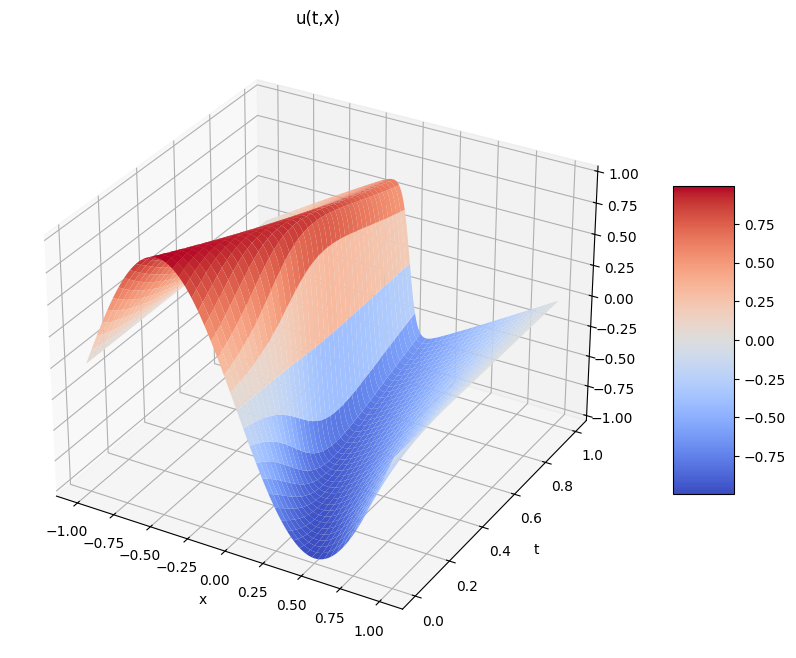

In [5]:
# test
# plot the figure
plot_u(40,400)

# NOTE:
# If a CUDA/GPU backend error appears during the first execution, it means that
# JAX tried to initialize the GPU while no compatible GPU was available.
# Re-running the cell usually makes JAX use the CPU backend instead.

We denote $z_m = (t_m, x_m)$ a space-time point in $[0,1] \times [-1,1]$, 
for $1 \leq m \leq M$.

We distinguish:
- interior points $z_1, \ldots, z_{M_\Omega}$,
- boundary (and initial) points $z_{M_\Omega+1}, \ldots, z_M$.

We then solve the following optimization problem:
$$
\min_{u \in \mathcal{H}(k)} \|u\|_{\mathcal{H}(k)}
\quad \text{s.t.} \quad
\begin{cases}
\mathcal{P}(u)(z_m) = f(z_m), & m = 1,\ldots,M_\Omega,\\
\mathcal{B}(u)(z_m) = g(z_m), & m = M_\Omega+1,\ldots,M.
\end{cases}
$$

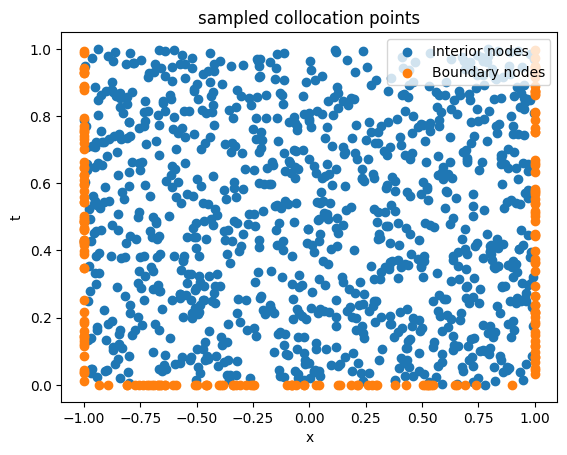

In [6]:
# sampled collocation points

def sample_points(N_domain, N_boundary):
    # interior nodes
    X_domain = random.uniform(0, 1.0, (N_domain, 2))
    X_domain[:,1] = 2*X_domain[:,1]-1
    X_boundary = onp.zeros((N_boundary, 2))

    # generate random boundary points on the faces of the domain 

    # bottom face
    X_boundary[:int(N_boundary/3), 1] = random.uniform(-1.0, 1.0, int(N_boundary/3)) # a remplir
    # right face
    X_boundary[int(N_boundary/3):2*int(N_boundary/3), 0] = random.uniform(0.0, 1.0, int(N_boundary/3)) 
    X_boundary[int(N_boundary/3):2*int(N_boundary/3), 1] = 1
    # left face
    X_boundary[2*int(N_boundary/3):, 0] = random.uniform(0.0, 1.0, int(N_boundary/3))
    X_boundary[2*int(N_boundary/3):, 1] = -1
    
    return X_domain, X_boundary

N_domain_tot = 1000
N_boundary_tot = 201

X_domain_tot, X_boundary_tot = sample_points(N_domain_tot, N_boundary_tot)

fig, ax = plt.subplots()
ax.scatter(X_domain_tot[range(N_domain_tot), 1], X_domain_tot[range(N_domain_tot), 0], label='Interior nodes')
ax.scatter(X_boundary_tot[range(N_boundary_tot), 1], X_boundary_tot[range(N_boundary_tot), 0], label='Boundary nodes')
ax.legend(loc="upper right")
ax.set_xlabel('x')
ax.set_ylabel('t')
plt.title('sampled collocation points')
plt.show()

Now, let us define kernels / covariance functions that are used to solve the PDEs

$$
k(z_1, z_2) 
= \exp\left(
- \frac{(t_1 - t_2)^2}{2\ell_t^2}
- \frac{(x_1 - x_2)^2}{2\ell_x^2}
\right),
$$
where $z_i = (t_i,x_i)$.

The parameters $\ell_t$ and $\ell_x$ denote the characteristic length-scales 
in time and space, respectively.


In [7]:
# Symbolic definition
x1, x2, y1, y2 = sp.symbols("x1 x2 y1 y2")
ell_t, ell_x = sp.symbols("ell_t ell_x", positive=True)

# Gaussian/RBF kernel
kappa_sym = sp.exp(
    -sp.Rational(1, 2) * (
        ((x1 - y1) / ell_t)**2
        + ((x2 - y2) / ell_x)**2
    )
)

# Symbolic derivatives
D_x1_sym = sp.diff(kappa_sym, x1)
D_x2_sym = sp.diff(kappa_sym, x2)
DD_x2_sym = sp.diff(kappa_sym, x2, 2)

D_y1_sym = sp.diff(kappa_sym, y1)
D_y2_sym = sp.diff(kappa_sym, y2)
DD_y2_sym = sp.diff(kappa_sym, y2, 2)

D_x1_D_y1_sym = sp.diff(kappa_sym, x1, y1)
D_x1_D_y2_sym = sp.diff(kappa_sym, x1, y2)
D_x1_DD_y2_sym = sp.diff(kappa_sym, x1, y2, 2)

D_x2_D_y2_sym = sp.diff(kappa_sym, x2, y2)
D_x2_DD_y2_sym = sp.diff(kappa_sym, x2, y2, 2)

DD_x2_DD_y2_sym = sp.diff(kappa_sym, x2, 2, y2, 2)


In [8]:
# Convert symbolic formulas to NumPy functions

variables = (x1, x2, y1, y2, ell_t, ell_x)

kappa_np = sp.lambdify(variables, kappa_sym, "numpy")

D_x1_np = sp.lambdify(variables, D_x1_sym, "numpy")
D_x2_np = sp.lambdify(variables, D_x2_sym, "numpy")
DD_x2_np = sp.lambdify(variables, DD_x2_sym, "numpy")

D_y1_np = sp.lambdify(variables, D_y1_sym, "numpy")
D_y2_np = sp.lambdify(variables, D_y2_sym, "numpy")
DD_y2_np = sp.lambdify(variables, DD_y2_sym, "numpy")

D_x1_D_y1_np = sp.lambdify(variables, D_x1_D_y1_sym, "numpy")
D_x1_D_y2_np = sp.lambdify(variables, D_x1_D_y2_sym, "numpy")
D_x1_DD_y2_np = sp.lambdify(variables, D_x1_DD_y2_sym, "numpy")

D_x2_D_y2_np = sp.lambdify(variables, D_x2_D_y2_sym, "numpy")
D_x2_DD_y2_np = sp.lambdify(variables, D_x2_DD_y2_sym, "numpy")

DD_x2_DD_y2_np = sp.lambdify(variables, DD_x2_DD_y2_sym, "numpy")

Now, we will construct the Gram matrix, based on the observation $u(z_i), u_t(z_i), u_x(z_i), u_{xx}(z_i)$

We organize all the variables in the way: $[v_1,v_2,v_3,v_0,v_b]$, where $v_0, v_1, v_2, v_3$ represent the interior nodal values of $u(z_i), u_t(z_i), u_x(z_i), u_{xx}(z_i)$, respectively; and $v_b$ is the boundary value. 

The Gram matrix $\Theta$ is then determined by this organization. Next code block is to construct this matrix.


In [9]:
def assembly_Theta(X_domain, X_boundary, nugget, ell):

    X_domain = onp.asarray(X_domain)
    X_boundary = onp.asarray(X_boundary)
    ell = onp.asarray(ell)

    N_domain = X_domain.shape[0]
    N_boundary = X_boundary.shape[0]

    Theta = onp.zeros((4 * N_domain + N_boundary,
                      4 * N_domain + N_boundary))

    ell_t = ell[0]
    ell_x = ell[1]

    # Interior points
    Xd0 = X_domain[:, 0]
    Xd1 = X_domain[:, 1]

    # Interior + boundary points
    Xdb0 = onp.concatenate([Xd0, X_boundary[:, 0]])
    Xdb1 = onp.concatenate([Xd1, X_boundary[:, 1]])

    # Interior vs interior
    XXdd0 = Xd0[:, None]
    XXdd1 = Xd1[:, None]
    YYdd0 = Xd0[None, :]
    YYdd1 = Xd1[None, :]

    # Interior + boundary vs interior + boundary
    XXdbdb0 = Xdb0[:, None]
    XXdbdb1 = Xdb1[:, None]
    YYdbdb0 = Xdb0[None, :]
    YYdbdb1 = Xdb1[None, :]

    # Interior vs interior + boundary
    XXddb0 = Xd0[:, None]
    XXddb1 = Xd1[:, None]
    YYddb0 = Xdb0[None, :]
    YYddb1 = Xdb1[None, :]

    # Interior vs interior blocks
    Theta[0:N_domain, 0:N_domain] = D_x1_D_y1_np(
        XXdd0, XXdd1, YYdd0, YYdd1, ell_t, ell_x
    )

    block = D_x1_D_y2_np(
        XXdd0, XXdd1, YYdd0, YYdd1, ell_t, ell_x
    )
    Theta[0:N_domain, N_domain:2*N_domain] = block
    Theta[N_domain:2*N_domain, 0:N_domain] = block.T

    block = D_x1_DD_y2_np(
        XXdd0, XXdd1, YYdd0, YYdd1, ell_t, ell_x
    )
    Theta[0:N_domain, 2*N_domain:3*N_domain] = block
    Theta[2*N_domain:3*N_domain, 0:N_domain] = block.T

    Theta[N_domain:2*N_domain, N_domain:2*N_domain] = D_x2_D_y2_np(
        XXdd0, XXdd1, YYdd0, YYdd1, ell_t, ell_x
    )

    block = D_x2_DD_y2_np(
        XXdd0, XXdd1, YYdd0, YYdd1, ell_t, ell_x
    )
    Theta[N_domain:2*N_domain, 2*N_domain:3*N_domain] = block
    Theta[2*N_domain:3*N_domain, N_domain:2*N_domain] = block.T

    Theta[2*N_domain:3*N_domain, 2*N_domain:3*N_domain] = DD_x2_DD_y2_np(
        XXdd0, XXdd1, YYdd0, YYdd1, ell_t, ell_x
    )

    # Interior + boundary vs interior + boundary
    Theta[3*N_domain:, 3*N_domain:] = kappa_np(
        XXdbdb0, XXdbdb1, YYdbdb0, YYdbdb1, ell_t, ell_x
    )

    # Interior vs interior + boundary blocks
    block = D_x1_np(
        XXddb0, XXddb1, YYddb0, YYddb1, ell_t, ell_x
    )
    Theta[0:N_domain, 3*N_domain:] = block
    Theta[3*N_domain:, 0:N_domain] = block.T

    block = D_x2_np(
        XXddb0, XXddb1, YYddb0, YYddb1, ell_t, ell_x
    )
    Theta[N_domain:2*N_domain, 3*N_domain:] = block
    Theta[3*N_domain:, N_domain:2*N_domain] = block.T

    block = DD_x2_np(
        XXddb0, XXddb1, YYddb0, YYddb1, ell_t, ell_x
    )
    Theta[2*N_domain:3*N_domain, 3*N_domain:] = block
    Theta[3*N_domain:, 2*N_domain:3*N_domain] = block.T

    # Trace-adaptive nugget regularization
    trace1 = onp.trace(Theta[:N_domain, :N_domain])
    trace2 = onp.trace(Theta[N_domain:2*N_domain, N_domain:2*N_domain])
    trace3 = onp.trace(Theta[2*N_domain:3*N_domain, 2*N_domain:3*N_domain])
    trace4 = onp.trace(Theta[3*N_domain:, 3*N_domain:])

    ratio = onp.array([
        trace1 / trace4,
        trace2 / trace4,
        trace3 / trace4
    ])

    temp = onp.concatenate(
        (
            ratio[0] * onp.ones(N_domain),
            ratio[1] * onp.ones(N_domain),
            ratio[2] * onp.ones(N_domain),
            onp.ones(N_domain + N_boundary)
        )
    )

    Theta = Theta + nugget * onp.diag(temp)

    L = jnp.linalg.cholesky(Theta)

    return L


From the implementation, we observe that the matrix $\Theta$ has a block structure of the form:
$$
\Theta =
\begin{bmatrix}
\Theta_{11} & \Theta_{12} & \Theta_{13} & \Theta_{14} \\
\Theta_{21} & \Theta_{22} & \Theta_{23} & \Theta_{24} \\
\Theta_{31} & \Theta_{32} & \Theta_{33} & \Theta_{34} \\
\Theta_{41} & \Theta_{42} & \Theta_{43} & \Theta_{44}
\end{bmatrix}.
$$



### **Question 1**

By inspecting the code, identify what each diagonal block corresponds to.

More precisely, what are the operators associated with:
- $\Theta_{11}$,
- $\Theta_{22}$,
- $\Theta_{33}$,
- $\Theta_{44}$ ?


<div style="background-color:#d4edda; padding:10px; border-radius:5px">

**Answer:**

<div>

In the above, we added trace-adaptive nugget terms to regularize the Gram matrix
\begin{equation*}
\Theta_{\lambda} = \Theta +
\text{nugget}\times\begin{bmatrix}
\lambda_1 I & 0 & 0 & 0\\
0 & \lambda_2 I & 0 & 0\\
0 & 0 & \lambda_3I & 0 \\
0 & 0 & 0 & I
\end{bmatrix}
\end{equation*}
where $\lambda_1, \lambda_2, \lambda_3$ are selected to be the trace ratios of the orginal Gram matrix

### **Question 2**

What is the role of this block-diagonal nugget term in the construction of the matrix $\Theta$?

<div style="background-color:#d4edda; padding:10px; border-radius:5px">

**Answer:**

<div>

### **Question 3**

Below we create the block matrix with regularization parameter `nugget = 1e-4`. What happens if we neglect this term?


In [12]:
L_matrix = assembly_Theta(X_domain_tot, X_boundary_tot, nugget = 1e-4 , ell = [1,1])
print(L_matrix)

[[ 1.0000416   0.          0.         ...  0.          0.
   0.        ]
 [ 0.24839833  0.96870095  0.         ...  0.          0.
   0.        ]
 [ 0.14431585  0.12061365  0.98219573 ...  0.          0.
   0.        ]
 ...
 [-0.07226016 -0.5391061   0.20710158 ...  0.00950889  0.
   0.        ]
 [-0.0131828  -0.29440257  0.49600208 ... -0.00124232  0.00922636
   0.        ]
 [-0.07633837 -0.55050474  0.17174873 ... -0.00100994 -0.00127376
   0.00949081]]


<div style="background-color:#d4edda; padding:10px; border-radius:5px">

**Answer:**

<div>

Then, we solve the following optimization problem  (with respect to v_0, v_1, v_2, v_3):
\begin{equation*}
\begin{aligned}
\min&\quad   [v_1,v_2,v_3,v_0,v_b]\Theta_{\lambda}^{-1} [v_1,v_2,v_3,v_0,v_b]^T\\
  \text{s.t.}&\quad v_1+\alpha v_0v_2-\nu v_3=f, \text{ and } v_b = \text{boundary data}
\end{aligned}
\end{equation*}

Here, $v_0, v_1, v_2, v_3$ represent the interior nodal values of $u(z_i), u_t(z_i), u_x(z_i), u_{xx}(z_i)$, respectively.

In [13]:
# loss functions
def J(v,rhs_f,bdy_g,L):
    N_domain = rhs_f.shape[0]
    v0 = v[:N_domain]
    v2 = v[N_domain:2*N_domain]
    v3 = v[2*N_domain:]
    
    vv = jnp.append(nu*v3+rhs_f-alpha*v0*v2, v2)
    vv = jnp.append(vv, v3)
    vv = jnp.append(vv, v0)
    vv = jnp.append(vv, bdy_g)
    temp = jnp.linalg.solve(L,vv)
    return jnp.dot(temp, temp)

# gradient of loss functions
grad_J = grad(J)

# Hessian in the Gaussian Newton method
import jax.numpy as jnp

def Hessian_GN(v, rhs_f, bdy_g, L):
    N_domain = rhs_f.shape[0]
    N_boundary = bdy_g.shape[0]

    v0 = v[:N_domain]
    v2 = v[N_domain:2*N_domain]
    v3 = v[2*N_domain:]  

    mtx = jnp.zeros((4 * N_domain + N_boundary, 3 * N_domain))

    mtx1 = jnp.concatenate(
        (-alpha * jnp.diag(v2), -alpha * jnp.diag(v0), nu * jnp.eye(N_domain)),
        axis=1
    )

    mtx = mtx.at[0:N_domain, :].set(mtx1)
    mtx = mtx.at[N_domain:2*N_domain, N_domain:2*N_domain].set(jnp.eye(N_domain))
    mtx = mtx.at[2*N_domain:3*N_domain, 2*N_domain:3*N_domain].set(jnp.eye(N_domain))
    mtx = mtx.at[3*N_domain:4*N_domain, :N_domain].set(jnp.eye(N_domain))

    ss = jnp.linalg.solve(L, mtx)
    return 2.0 * (ss.T @ ss)


# solve PDEs
def pde_solver(X_domain, X_boundary, nugget, max_iter, initial_sol, set_sigma, output_history = 0):
    N_domain = X_domain.shape[0]
    
    rhs_f = vmap(f)(X_domain[:,0], X_domain[:,1])  # rhs data
    bdy_g = vmap(u)(X_boundary[:,0], X_boundary[:,1]) # boundary data
    
    L = assembly_Theta(X_domain, X_boundary, nugget, set_sigma)
    sol = initial_sol
    step_size = 1
    
    J_hist = [] # history of loss function values
    J_now = J(sol,rhs_f,bdy_g,L)
    J_hist.append(J_now)
    
    for iter_step in range(max_iter):
        temp = jnp.linalg.solve(Hessian_GN(sol,rhs_f,bdy_g,L), grad_J(sol,rhs_f,bdy_g,L))
        sol = sol - step_size*temp
        
        if output_history == 1:
            J_now = J(sol,rhs_f,bdy_g,L)
            J_hist.append(J_now)
            print('iter = ', iter_step, 'Gauss-Newton step size =', step_size, ' J = ', J_now)
    J_now = J(sol,rhs_f,bdy_g,L)
    return sol, J_hist, J_now, L

### **Question 4**

In the code, this problem is reformulated as an unconstrained minimization problem with respect to the vector `v = [v_0, v_2, v_3]`

The optimization problem becomes:
$$
\min_{v_0, v_2, v_3}
\quad
[v_1, v_2, v_3, v_0, v_b]\,
\Theta_{\lambda}^{-1}\,
[v_1, v_2, v_3, v_0, v_b]^T.
$$

In this reformulation, the variables $v_1$ and $v_b$ are no longer treated as independent unknowns. How are they computed from $v_0$, $v_2$, $v_3$, and the data?


<div style="background-color:#d4edda; padding:10px; border-radius:5px">

**Answer:**

<div>

Given a test grid
$$
X_{\text{test}} = \{(t_i^{\text{test}}, x_i^{\text{test}})\}_{i=1}^{N_{\text{test}}},
$$
the reconstructed solution is given by
$$
u^\star(X_{\text{test}})
=
\Theta(X_{\text{test}}, X_{\text{train}})\,
\Theta_\lambda^{-1}
\begin{bmatrix}
v_1\\
v_2\\
v_3\\
v_0\\
v_b
\end{bmatrix}.
$$

In the code, the matrix
$
\Theta(X_{\text{test}}, X_{\text{train}})
$
is constructed by the function `construct_inpTheta`.

In [14]:
def construct_inpTheta(X_test, X_domain, X_boundary, ell):
    N_domain = X_domain.shape[0]
    N_boundary = X_boundary.shape[0]
    N_test = X_test.shape[0]

    ell_t = ell[0]
    ell_x = ell[1]

    inpTheta = onp.zeros((N_test, 4 * N_domain + N_boundary))

    # X_test coordinates
    Xt0 = X_test[:, 0]
    Xt1 = X_test[:, 1]

    # Interior points coordinates
    Xd0 = X_domain[:, 0]
    Xd1 = X_domain[:, 1]

    # Interior + boundary points coordinates
    Xdb0 = onp.concatenate([Xd0, X_boundary[:, 0]])
    Xdb1 = onp.concatenate([Xd1, X_boundary[:, 1]])

    # Test vs interior
    XXtd0 = Xt0[:, None]
    XXtd1 = Xt1[:, None]
    YYtd0 = Xd0[None, :]
    YYtd1 = Xd1[None, :]

    # Test vs interior + boundary
    XXtdb0 = Xt0[:, None]
    XXtdb1 = Xt1[:, None]
    YYtdb0 = Xdb0[None, :]
    YYtdb1 = Xdb1[None, :]

    inpTheta[:, :N_domain] = D_y1_np(
        XXtd0, XXtd1, YYtd0, YYtd1, ell_t, ell_x
    )

    inpTheta[:, N_domain:2*N_domain] = D_y2_np(
        XXtd0, XXtd1, YYtd0, YYtd1, ell_t, ell_x
    )

    inpTheta[:, 2*N_domain:3*N_domain] = DD_y2_np(
        XXtd0, XXtd1, YYtd0, YYtd1, ell_t, ell_x
    )

    inpTheta[:, 3*N_domain:] = kappa_np(
        XXtdb0, XXtdb1, YYtdb0, YYtdb1, ell_t, ell_x
    )

    return inpTheta

In the code, the matrix
$
\Theta(X_{\text{test}}, X_{\text{train}})
$
is constructed by the function `construct_inpTheta`.

This matrix has the following block structure:
$$
\Theta(X_{\text{test}}, X_{\text{train}})
=
\begin{bmatrix}
\Theta_{u,v_1} & \Theta_{u,v_2} & \Theta_{u,v_3} & \Theta_{u,v_0,v_b}
\end{bmatrix}.
$$

### **Question 5**

By inspecting the function `construct_inpTheta`, identify the kernel expressions used in each block of 
$
\Theta(X_{\text{test}}, X_{\text{train}}).
$

More precisely, determine the blocks corresponding to:

- $\Theta_{u,v_1}$,
- $\Theta_{u,v_2}$,
- $\Theta_{u,v_3}$,
- $\Theta_{u,v_0,v_b}$.

For each block, give its dimension.

Finally, what is the dimension of the full matrix
$\Theta(X_{\text{test}}, X_{\text{train}})?
$

<div style="background-color:#d4edda; padding:10px; border-radius:5px">

**Answer:**

<div>

In [15]:
def extend_solution(X_test, L, v, ell):
        
    inp_Theta = construct_inpTheta(X_test, X_domain_tot, X_boundary_tot, ell)
    
    aux = jnp.linalg.solve(jnp.transpose(L),jnp.linalg.solve(L,v))
    
    extended_u = onp.matmul(inp_Theta,aux)
    return extended_u


def sol_time_t(t, num_pts, sol, L, ell):
    xx=t
    yy = onp.linspace(-1, 1, num_pts)
    XX, YY = onp.meshgrid(xx, yy)

    # vectorized (x,y) coordinates
    XXv = onp.array(XX.flatten())
    YYv = onp.array(YY.flatten())
    XXv=onp.expand_dims(XXv, axis=1) 
    YYv=onp.expand_dims(YYv, axis=1) 

    X_test=jnp.concatenate((XXv,YYv), axis=1)
    
    rhs_f = vmap(f)(X_domain_tot[:,0], X_domain_tot[:,1])  
    bdy_g = vmap(u)(X_boundary_tot[:,0], X_boundary_tot[:,1])
    v0 = sol[:N_domain_tot]
    v2 = sol[N_domain_tot:2*N_domain_tot]
    v3 = sol[2*N_domain_tot:]
    vv = jnp.concatenate((nu*v3+rhs_f-alpha*v0*v2, v2, v3, v0, bdy_g), axis=0)
    
    extended_u = extend_solution(X_test, L, vv, ell)
    u_truth=vmap(u_true)(XXv, YYv)
    u_truth=u_truth.flatten()
    
    # L2err
    L2err = onp.sqrt(onp.sum((extended_u-u_truth)**2)/(num_pts))
    # Maxerr
    Maxerr = onp.max(abs(extended_u-u_truth))
    
    return yy, extended_u, u_truth, L2err, Maxerr

def sol_time_space(num_pts_time, num_pts_space, sol, L, ell):
    xx= onp.linspace(0, 1, num_pts_time)
    yy = onp.linspace(-1, 1, num_pts_space)
    XX, YY = onp.meshgrid(xx, yy)

    # vectorized (x,y) coordinates
    XXv = onp.array(XX.flatten())
    YYv = onp.array(YY.flatten())
    XXv=onp.expand_dims(XXv, axis=1) 
    YYv=onp.expand_dims(YYv, axis=1) 

    X_test=jnp.concatenate((XXv,YYv), axis=1)
    
    rhs_f = vmap(f)(X_domain_tot[:,0], X_domain_tot[:,1])  
    bdy_g = vmap(u)(X_boundary_tot[:,0], X_boundary_tot[:,1])
    v0 = sol[:N_domain_tot]
    v2 = sol[N_domain_tot:2*N_domain_tot]
    v3 = sol[2*N_domain_tot:]
    vv = jnp.concatenate((nu*v3+rhs_f-alpha*v0*v2, v2, v3, v0, bdy_g), axis=0)
    
    extended_u = extend_solution(X_test, L, vv, ell)
    extended_u = extended_u.reshape(num_pts_space, num_pts_time)
    
    u_truth = onp.vectorize(u_true)(XXv, YYv)
    u_truth = u_truth.reshape(num_pts_space, num_pts_time)
    
    # L2err
    L2err = onp.linalg.norm(extended_u-u_truth,'fro')/(onp.sqrt(num_pts_space*num_pts_time))
    
    # Maxerr
    Maxerr = onp.max(abs(extended_u-u_truth))
    
    return XX, YY, extended_u, u_truth, L2err, Maxerr

### **Question 6**

Complete the following code by choosing appropriate values for the model and solver parameters.

In [22]:
nugget = 1e-4  # TODO: choose a small positive value
max_iter = 10  # TODO: choose the number of iterations 
initial_sol = random.normal(0, 1.0, (3 * N_domain_tot)) # Initial guess for the unknown vector v = [v0, v2, v3]


ell = jnp.array([0.47, 0.07])  # TODO: Kernel length-scale parameters: [ell_t, ell_x]

print(f'parameter (l_t, l_x) is set to be {ell}')

# Solve the PDE using the GP-based method
sol, J_hist, J_final, L = pde_solver(
    X_domain_tot,
    X_boundary_tot,
    nugget,
    max_iter,
    initial_sol,
    ell,
    1
)

parameter (l_t, l_x) is set to be [0.47 0.07]
iter =  0 Gauss-Newton step size = 1  J =  539192.9
iter =  1 Gauss-Newton step size = 1  J =  274786.66
iter =  2 Gauss-Newton step size = 1  J =  955930.7
iter =  3 Gauss-Newton step size = 1  J =  13903.583
iter =  4 Gauss-Newton step size = 1  J =  370.48105
iter =  5 Gauss-Newton step size = 1  J =  267.4411
iter =  6 Gauss-Newton step size = 1  J =  263.27524
iter =  7 Gauss-Newton step size = 1  J =  261.16403
iter =  8 Gauss-Newton step size = 1  J =  260.12106
iter =  9 Gauss-Newton step size = 1  J =  259.55048


### **Question 7**

To evaluate the reconstructed solution, build a regular test grid using `num_pts_time` points in time and `num_pts_space` points in space.

Then, choose three different time values `t` to visualize one-dimensional sections of the solution.

**Important:** the selected values of `t` must belong to the test time grid.

In [23]:
# Number of test points in time and space
num_pts_time = 30   # TODO
num_pts_space = 100  # TODO

# Compute the reconstructed solution on the full space-time grid
XX, YY, extended_u, u_truth, space_time_L2err, space_time_Maxerr = sol_time_space(
    num_pts_time,
    num_pts_space,
    sol,
    L,
    ell
)

# Choose three time values for visualization
# Important: each value of t must belong to the test time grid
t = 0.2  # TODO
yy, extended_u_t1, u_truth_t1, L2err_t1, Maxerr_t1 = sol_time_t(
    t,
    num_pts_space,
    sol,
    L,
    ell
)

t = 0.5  # TODO
yy, extended_u_t2, u_truth_t2, L2err_t2, Maxerr_t2 = sol_time_t(
    t,
    num_pts_space,
    sol,
    L,
    ell
)

t = 0.8  # TODO
yy, extended_u_t3, u_truth_t3, L2err_t3, Maxerr_t3 = sol_time_t(
    t,
    num_pts_space,
    sol,
    L,
    ell
)

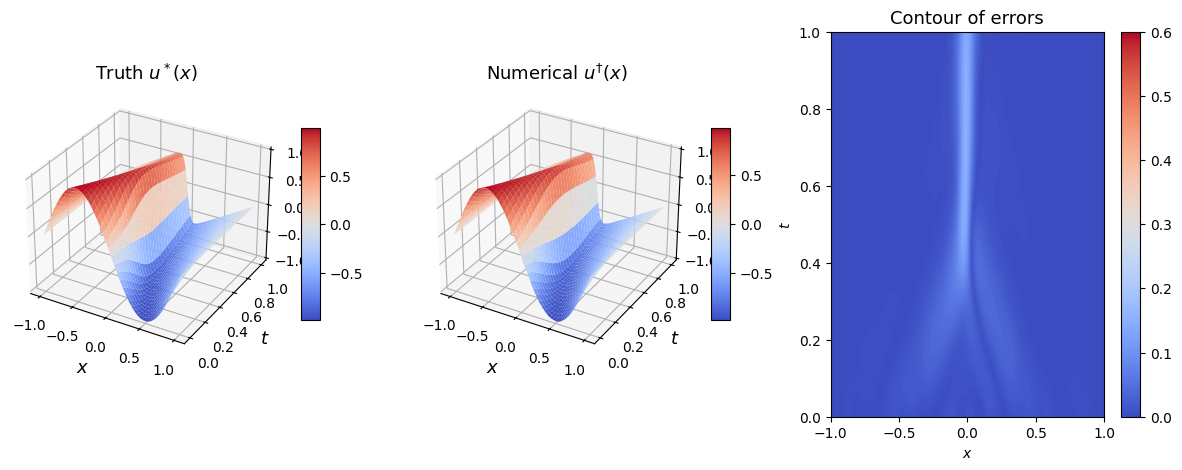

(l_t, l_x)= [0.47 0.07] , nugget = 0.0001 , # pts:  1201 
 space-time L2 error:  0.02326443241053505 , max err:  0.1517618643323857


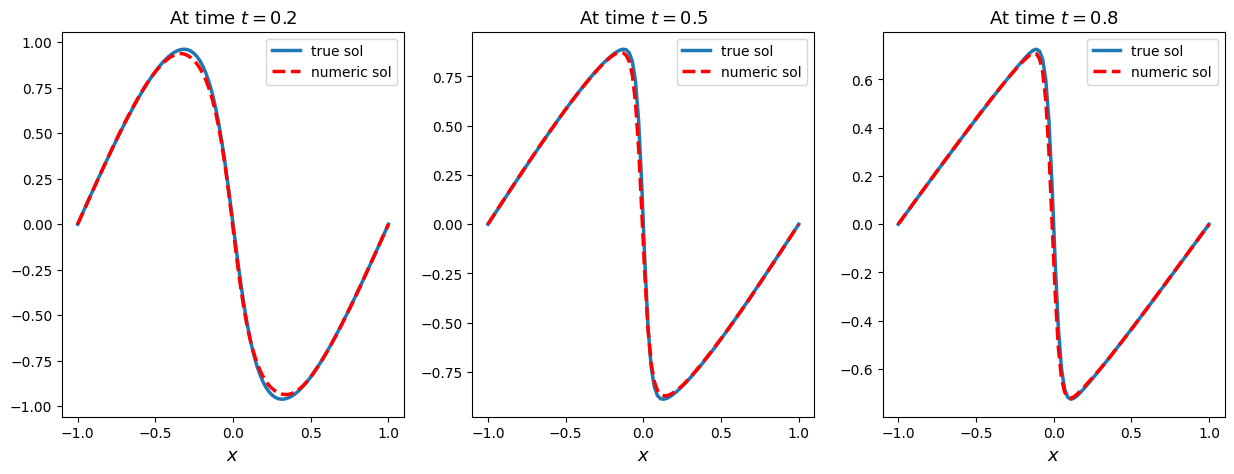

t=0.2, L2 error:  0.017108347 , max err:  0.04151392
t=0.5, L2 error:  0.025456801 , max err:  0.14179677
t=0.8, L2 error:  0.027751343 , max err:  0.15152518


In [24]:
# plot figures
here_fontsize=13

# --------------space time plot---------------------
fig = plt.figure(figsize=(15,5))

ax = fig.add_subplot(131, projection='3d')
u_sol_surf=ax.plot_surface(YY, XX, u_truth, cmap=plt.cm.coolwarm)
plt.xlabel('$x$', fontsize=here_fontsize)
plt.ylabel('$t$', fontsize=here_fontsize) 
plt.title('Truth $u^*(x)$', fontsize=here_fontsize)
fig.colorbar(u_sol_surf, shrink= 0.5, aspect = 10)


# plot the numerical solution
ax = fig.add_subplot(132, projection='3d')
u_sol_surf=ax.plot_surface(YY, XX, extended_u, cmap=plt.cm.coolwarm)
plt.xlabel('$x$', fontsize=here_fontsize)
plt.ylabel('$t$', fontsize=here_fontsize) 
plt.title('Numerical $u^{\dagger}(x)$', fontsize=here_fontsize)
fig.colorbar(u_sol_surf, shrink= 0.5, aspect = 10)

# contourf
ax = fig.add_subplot(133)
error_field = abs(extended_u - u_truth)
contour = ax.contourf(YY, XX, error_field, 50, cmap=plt.cm.coolwarm, vmin=0, vmax=0.6)
ax.set_title("Contour of errors", fontsize=here_fontsize)
ax.set_xlabel("$x$")
ax.set_ylabel("$t$")

norm = mcolors.Normalize(vmin=0, vmax=0.6)
mappable = cm.ScalarMappable(norm=norm, cmap=plt.cm.coolwarm)
fig.colorbar(mappable, ax=ax)


plt.show()
fig.tight_layout()

# fig.savefig('Burgers_pts1500_sol_contour_plt.pdf', bbox_inches='tight',dpi=100,pad_inches=0.1)

print('(l_t, l_x)=', ell, ', nugget =', nugget, ', # pts: ', N_domain_tot+N_boundary_tot, '\n space-time L2 error: ', space_time_L2err, ', max err: ', space_time_Maxerr)

# ---------------time slice plot--------------------
fig = plt.figure(figsize=(15,5))

# plot the numerical solution
ax = fig.add_subplot(131)
ax.plot(yy, u_truth_t1, linewidth=2.5, label='true sol')
ax.plot(yy, extended_u_t1, linestyle='dashed', linewidth=2.5, color='red', label='numeric sol')
ax.set_xlabel('$x$', fontsize=here_fontsize)
ax.legend()
plt.title('At time $t = 0.2$', fontsize=here_fontsize)

ax = fig.add_subplot(132)
ax.plot(yy, u_truth_t2, linewidth=2.5, label='true sol')
ax.plot(yy, extended_u_t2, linestyle='dashed', linewidth=2.5, color='red', label='numeric sol')
ax.set_xlabel('$x$', fontsize=here_fontsize)
ax.legend()
plt.title('At time $t = 0.5$', fontsize=here_fontsize)

ax = fig.add_subplot(133)
ax.plot(yy, u_truth_t3, linewidth=2.5, label='true sol')
ax.plot(yy, extended_u_t3, linestyle='dashed', linewidth=2.5, color='red', label='numeric sol')
ax.set_xlabel('$x$', fontsize=here_fontsize)
ax.legend()
plt.title('At time $t = 0.8$',fontsize=here_fontsize)

plt.show()
fig.tight_layout()
# fig.savefig('Burgers_pts1500_time_sol_plt.pdf', bbox_inches='tight',dpi=100,pad_inches=0.1)

print('t=0.2, L2 error: ', L2err_t1 , ', max err: ', Maxerr_t1)
print('t=0.5, L2 error: ', L2err_t2 , ', max err: ', Maxerr_t2)
print('t=0.8, L2 error: ', L2err_t3 , ', max err: ', Maxerr_t3)



### **Bonus Question**

Replace the Gaussian (RBF) kernel by a Matérn $5/2$ kernel.

For two space-time points
$$
\mathbf{x}=(x_1,x_2), \qquad \mathbf{y}=(y_1,y_2),
$$
we define
$$
r =
\sqrt{
\left(\frac{x_1-y_1}{\ell_t}\right)^2
+
\left(\frac{x_2-y_2}{\ell_x}\right)^2
}.
$$

The Matérn \(5/2\) kernel is then given by
$$
k(\mathbf{x},\mathbf{y})
=
\left(
1 + \sqrt{5}r + \frac{5}{3}r^2
\right)
\exp(-\sqrt{5}r).
$$

Implement this kernel in place of the Gaussian kernel, and compare the results.